# Run PeakVI on in vitro blood multiome ATAC

In [1]:
import scvi
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
sc.set_figure_params(figsize=(8, 8))

Global seed set to 0
/home/bt392/miniconda3/envs/env_all/lib/python3.8/site-packages/pytorch_lightning/utilities/warnings.py:53: LightningDeprecationWarning: pytorch_lightning.utilities.warnings.rank_zero_deprecation has been deprecated in v1.6 and will be removed in v1.8. Use the equivalent function from the pytorch_lightning.utilities.rank_zero module instead.
  new_rank_zero_deprecation(
/home/bt392/miniconda3/envs/env_all/lib/python3.8/site-packages/pytorch_lightning/utilities/warnings.py:58: LightningDeprecationWarning: The `pytorch_lightning.loggers.base.rank_zero_experiment` is deprecated in v1.7 and will be removed in v1.9. Please use `pytorch_lightning.loggers.logger.rank_zero_experiment` instead.
  return new_rank_zero_deprecation(*args, **kwargs)


In [2]:
basedir = '/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/atac/archR/dimensionality_reduction/peakVI/'

In [3]:
adata = sc.read_h5ad(basedir + 'anndata_ATAC_variable.h5ad')

In [4]:
adata

AnnData object with n_obs × n_vars = 33177 × 35000
    obs: 'barcode', 'sample', 'nFeature_RNA', 'nCount_RNA', 'mitochondrial_percent_RNA', 'ribosomal_percent_RNA', 'alias', 'day', 'genotype', 'doublet_score', 'celltype', 'celltype.score', 'closest.cell', 'day_celltype', 'celltype_genotype', 'TSSEnrichment_atac', 'ReadsInTSS_atac', 'PromoterRatio_atac', 'NucleosomeRatio_atac', 'nFrags_atac', 'BlacklistRatio_atac', 'exp'
    var: 'idx'

In [5]:
adata.X = adata.X.tocsr()

In [6]:
print(adata.shape)
# compute the threshold: 5% of the cells
min_cells = int(adata.shape[0] * 0.05)
# in-place filtering of regions
sc.pp.filter_genes(adata, min_cells=min_cells)
print(adata.shape)

(33177, 35000)
(33177, 29846)


In [9]:
scvi.model.PEAKVI.setup_anndata(adata,
    batch_key="exp",
    categorical_covariate_keys=["day"])

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [10]:
pvi = scvi.model.PEAKVI(adata,
                       n_hidden = 128,
                       n_latent = 15)
pvi.train()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/home/bt392/miniconda3/envs/env_all/lib/python3.8/site-packages/pytorch_lightning/trainer/configuration_validator.py:267: LightningDeprecationWarning: The `Callback.on_epoch_end` hook was deprecated in v1.6 and will be removed in v1.8. Please use `Callback.on_<train/validation/test>_epoch_end` instead.
  rank_zero_deprecation(


Epoch 281/500:  56%|█████▌    | 281/500 [6:03:25<4:43:14, 77.60s/it, loss=1.64e+08, v_num=1]
Monitored metric reconstruction_loss_validation did not improve in the last 50 records. Best score: 10830.414. Signaling Trainer to stop.


In [11]:
pvi.save(basedir + 'peakvi_model/')

In [7]:
pvi = scvi.model.PEAKVI.load(basedir +  "peakvi_model/", adata=adata)

INFO     File                                                                                                      
         /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/atac/archR/dimensionality_reductio
         n/peakVI/peakvi_model/model.pt already downloaded                                                         


No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [8]:
latent = pvi.get_latent_representation()
adata.obsm["X_PeakVI"] = latent

print(latent.shape)

(33177, 15)


In [9]:
# compute the k-nearest-neighbor graph that is used in both clustering and umap algorithms
sc.pp.neighbors(adata, use_rep="X_PeakVI")
# compute the umap
sc.tl.umap(adata, min_dist=0.2)
# cluster the space (we use a lower resolution to get fewer clusters than the default)
#sc.tl.leiden(adata, key_added="cluster_pvi", resolution=0.2)

/home/bt392/miniconda3/envs/env_all/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/bt392/miniconda3/envs/env_all/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


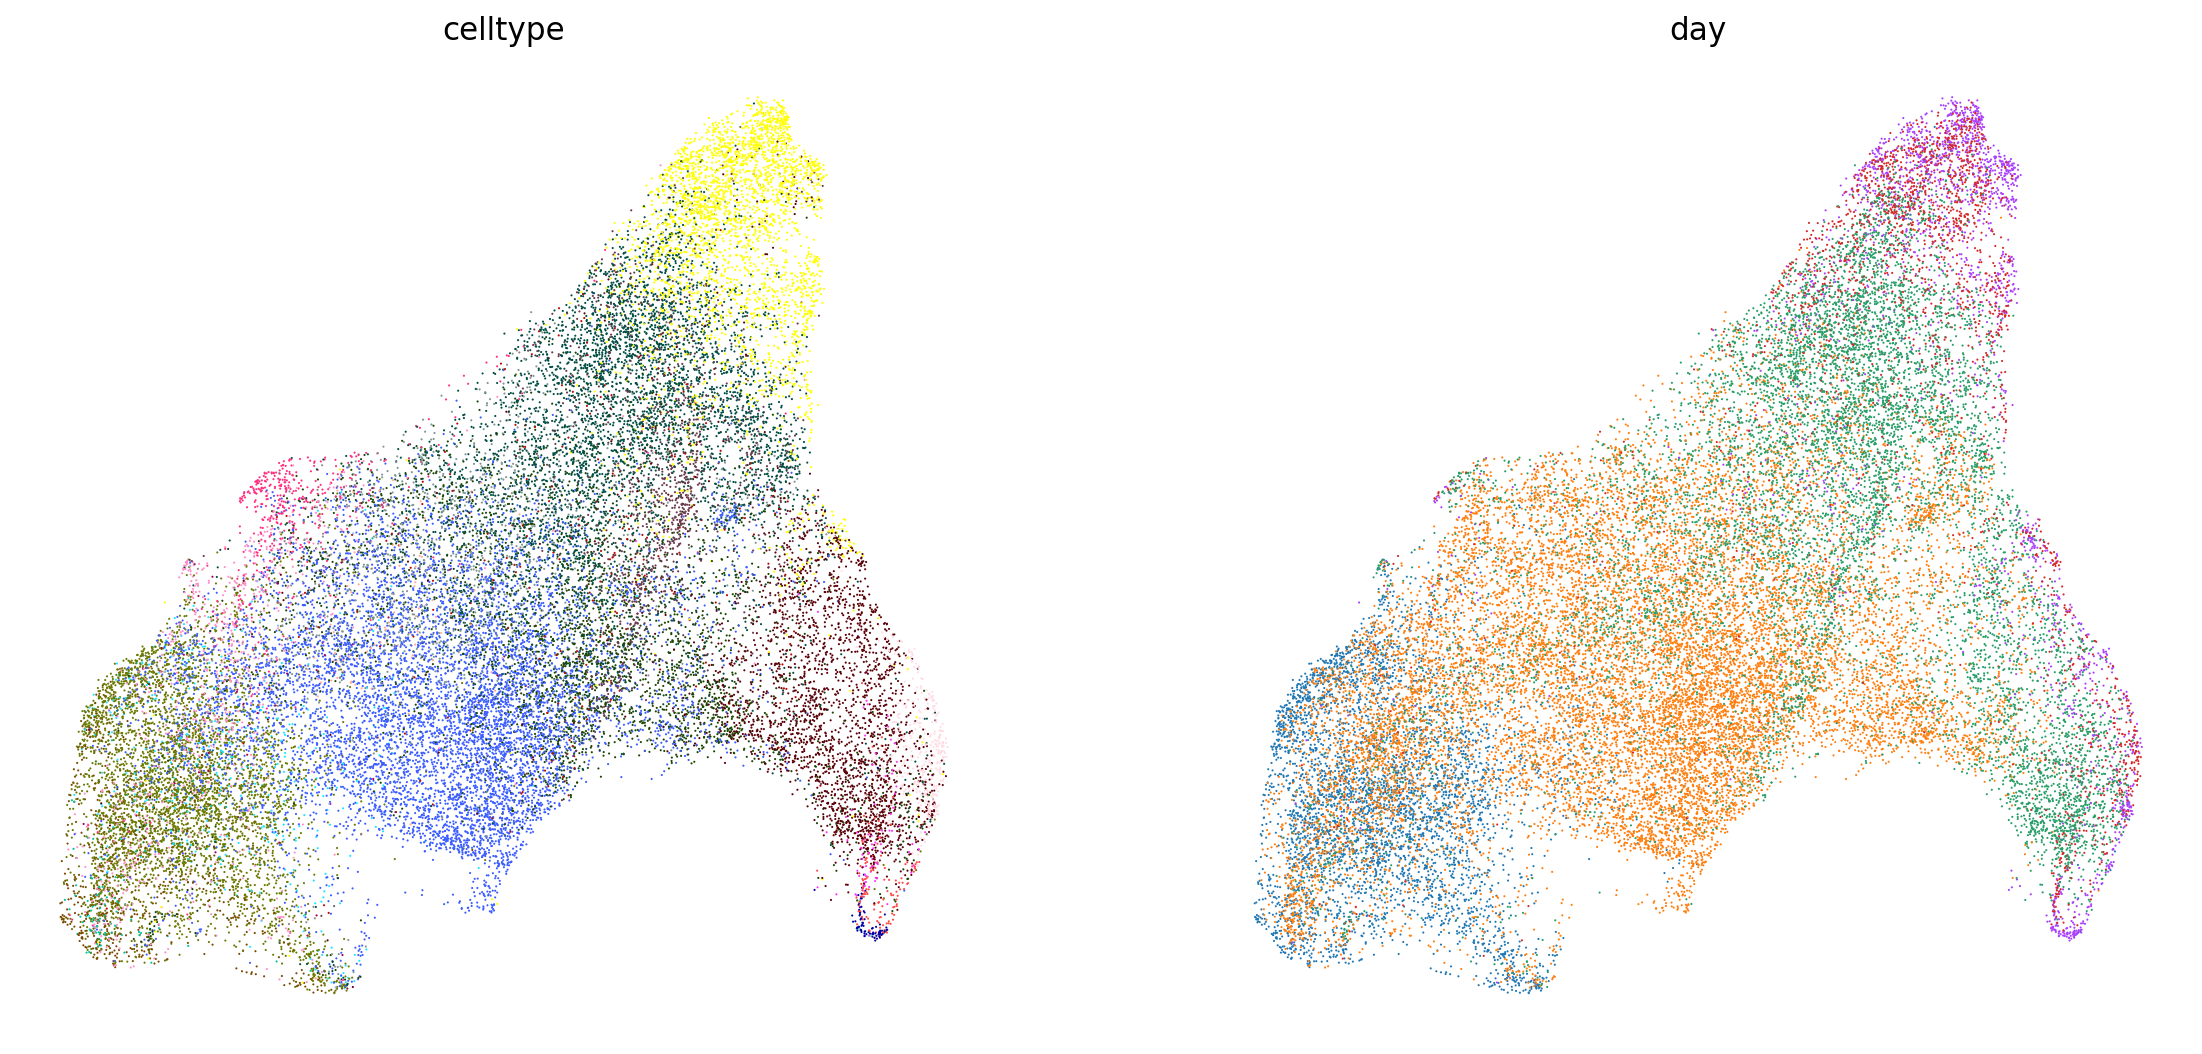

In [10]:
sc.pl.umap(
    adata,
    color=["celltype", "day"],
    frameon=False,
    ncols=2, legend_loc='none'
)

In [11]:
umap = pd.DataFrame(adata.obsm['X_umap'])
latent = pd.DataFrame(adata.obsm['X_PeakVI'])

umap.to_csv(basedir + 'peakVI_umap.csv')
latent.to_csv(basedir + 'peakVI_latent.csv')